In [17]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns


def make_decision_boundary_classifier(model):
    class DecisionBoundaryClassifier:
        def __init__(self, model):
            self.model = model
            self.classes_ = np.array([0, 1])

        def predict(self, X):
            probs = self.model.predict(X, verbose=0).ravel()
            return (probs >= 0.5).astype(int)

    return DecisionBoundaryClassifier(model)


In [7]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

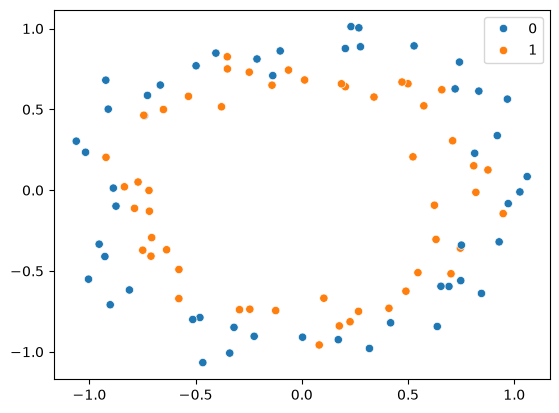

In [8]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

In [10]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

d:\Projects\Deep Learning\.deepLearning\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, verbose=0)

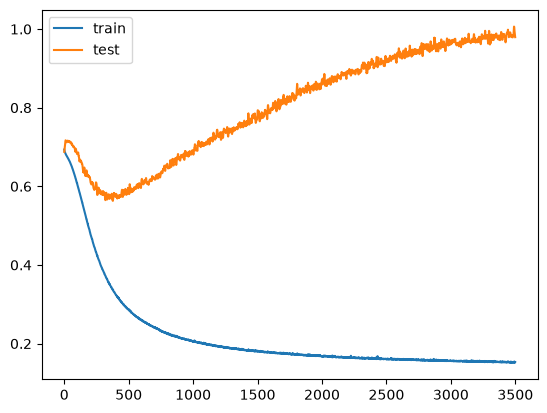

In [13]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

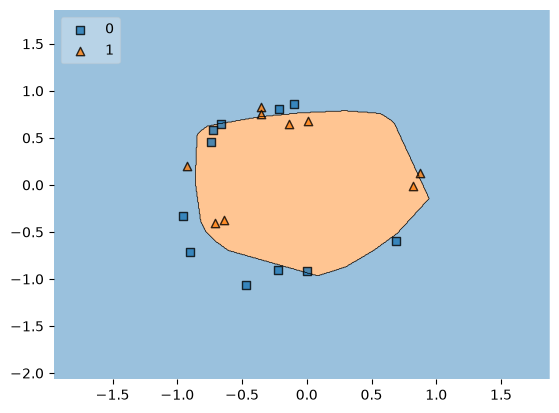

In [18]:
clf = make_decision_boundary_classifier(model)
plot_decision_regions(X_test, y_test.ravel(), clf=clf, legend=2)
plt.show()

# Early Stopping

In [19]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [20]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [22]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5125 - loss: 0.7003 - val_accuracy: 0.4500 - val_loss: 0.7118
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.6975 - val_accuracy: 0.3500 - val_loss: 0.7121
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5500 - loss: 0.6949 - val_accuracy: 0.3500 - val_loss: 0.7147
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5500 - loss: 0.6943 - val_accuracy: 0.2500 - val_loss: 0.7164
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5375 - loss: 0.6927 - val_accuracy: 0.2500 - val_loss: 0.7184
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5375 - loss: 0.6913 - val_accuracy: 0.2500 - val_loss: 0.7195
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5500 - loss: 0.6905 - val_accuracy: 0.2500 - val_loss: 0.7196
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5375 - loss: 0.6895 - val_accuracy: 0.3000 - val_loss: 0.72

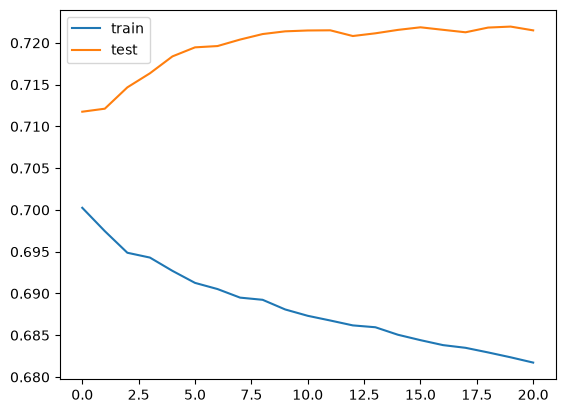

In [23]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

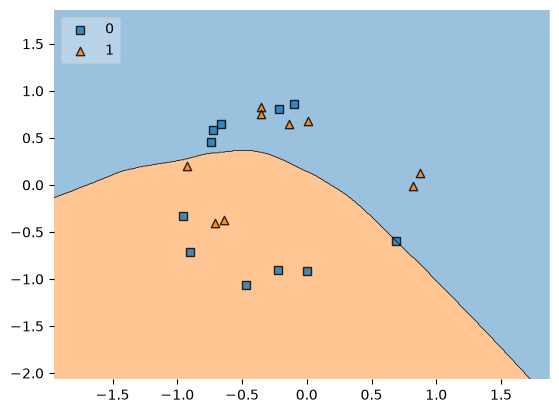

In [24]:
clf = make_decision_boundary_classifier(model)
plot_decision_regions(X_test, y_test.ravel(), clf=clf, legend=2)
plt.show()